## Applying ML techniques to Quantum and Executing them to the IBM_Hardware

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

from qiskit.circuit.library import (
    zz_feature_map,
    real_amplitudes
)

from qiskit_ibm_runtime import (
    QiskitRuntimeService,
    SamplerV2 as Sampler
)

from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit_machine_learning.algorithms.classifiers import VQC
from qiskit_machine_learning.optimizers import COBYLA
from qiskit_machine_learning.utils import algorithm_globals

In [2]:
algorithm_globals.random_seed = 42
np.random.seed(42)

In [3]:
features , labels = make_moons(
    n_samples=40,
    noise=0.15,
    random_state=42
)

In [4]:
scaler = MinMaxScaler()

features = scaler.fit_transform(features)

In [5]:
print(features.shape)
print(labels.shape)

(40, 2)
(40,)


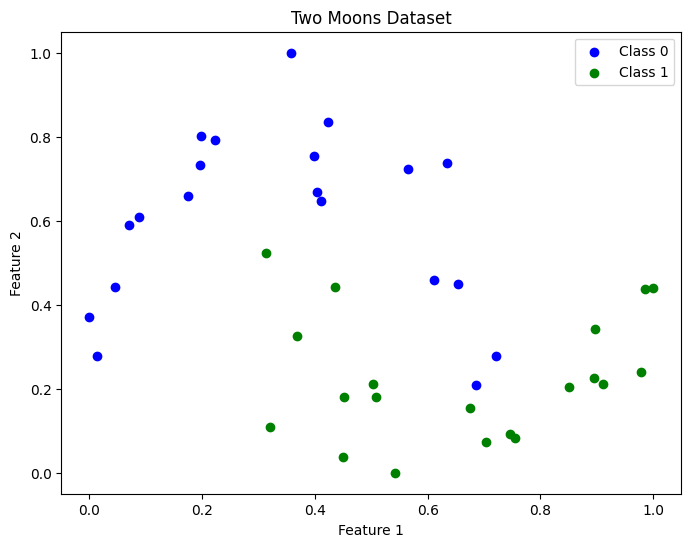

In [6]:
def plot_dataset():
    plt.figure(figsize=(8,6))

    plt.scatter(
        features[labels == 0, 0],
        features[labels == 0, 1],
        color="blue",
        label="Class 0"
    )

    plt.scatter(
        features[labels == 1, 0],
        features[labels == 1, 1],
        color="green",
        label="Class 1"
    )

    plt.title("Two Moons Dataset")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

    plt.legend()
    plt.show()

plot_dataset()

In [7]:
train_features , test_features , train_labels , test_lables = train_test_split(
    features , labels , test_size=0.2 , random_state=42
)

In [8]:
encoder = OneHotEncoder(sparse_output=False)

train_labels = encoder.fit_transform(
    train_labels.reshape(-1 , 1)
)

test_lables = encoder.transform(
    test_lables.reshape(-1 , 1)
)

In [9]:
print(train_labels.shape)
print(test_lables.shape)

(32, 2)
(8, 2)


In [10]:
QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="w9GtXjVFHO9hPy8MTyyQxImc_kpoVjkzpIq1WAmS1Dt8",
    overwrite=True
)

In [11]:
service = QiskitRuntimeService()
print(service.backends())

qiskit_runtime_service.__init__:WARNING:2026-05-27 16:33:28,897: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-05-27 16:33:28,898: Loading instance: open-instance, plan: open


[<IBMBackend('ibm_kingston')>, <IBMBackend('ibm_marrakesh')>, <IBMBackend('ibm_fez')>]


In [12]:
least_busy_backend = service.least_busy(
    simulator=False,
    operational=True,
    min_num_qubits=2
)

qiskit_runtime_service.backends:WARNING:2026-05-27 16:33:32,276: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-05-27 16:33:35,195: Using instance: open-instance, plan: open


In [13]:
backend = least_busy_backend

In [14]:
pass_manager = generate_preset_pass_manager(
    backend=backend,
    optimization_level=1
)

In [15]:
sampler = Sampler(
    mode=backend,
    options={
        "default_shots": 128
    }
)

In [16]:
feature_map = zz_feature_map(
    feature_dimension=2,
    reps=2
)

In [17]:
ansatz = real_amplitudes(
    num_qubits=2,
    reps=2
)

In [18]:
optimizer = COBYLA(
    maxiter=25
)

In [19]:
vqc = VQC(
    sampler=sampler,
    ansatz=ansatz,
    feature_map=feature_map,
    optimizer=optimizer,
    pass_manager=pass_manager
)

In [25]:
vqc.fit(train_features, train_labels)

In [26]:
train_score = vqc.score(
    train_features,
    train_labels
)

test_score = vqc.score(
    test_features,
    test_lables
)

print("Train Accuracy :", train_score)
print("Test Accuracy  :", test_score)

Train Accuracy : 0.65625
Test Accuracy  : 0.5


In [27]:
train_predictions = vqc.predict(train_features)

test_predictions = vqc.predict(test_features)

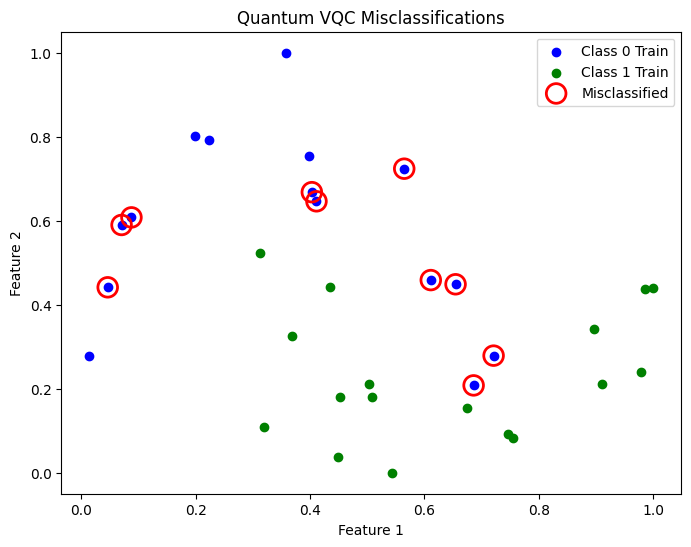

In [28]:
# Convert one-hot labels to integer labels
train_labels_int = np.argmax(train_labels, axis=1)

# Convert predictions to integer labels
train_predictions_int = np.argmax(train_predictions, axis=1)

plt.figure(figsize=(8,6))

# Class 0
plt.scatter(
    train_features[train_labels_int == 0, 0],
    train_features[train_labels_int == 0, 1],
    color="blue",
    label="Class 0 Train"
)

# Class 1
plt.scatter(
    train_features[train_labels_int == 1, 0],
    train_features[train_labels_int == 1, 1],
    color="green",
    label="Class 1 Train"
)

# Misclassified points
plt.scatter(
    train_features[train_labels_int != train_predictions_int, 0],
    train_features[train_labels_int != train_predictions_int, 1],
    s=200,
    facecolors="none",
    edgecolors="red",
    linewidths=2,
    label="Misclassified"
)

plt.title("Quantum VQC Misclassifications")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.legend()
plt.show()